# RadIAnce: Parametric Roof Irradiance Emulation Framework

In this notebook, you will develop an emulator for the annual irradiance and surface area of a parametric roof. The roof geometry is characterized by eight predefined geometric parameters. A computational model has been used to evaluate the yearly irradiance on a mesh discretization of the reconstructed roof; the outputs may therefore be affected by numerical errors.
The goal is to enable efficient solar potential assessment for energy systems analysis and design optimization.

Using Monte Carlo sampling, a dataset has been constructed consisting of 20000 parameter instances and their corresponding two-dimensional outputs. The data are provided in the file `SCTdata20K.csv`.

Note that the ranges of the eight parameters are defined in the following array:

In [1]:
import numpy as np
ranges = np.array([
    [0,5],  #p1
    [0,10], #p2
    [0,5],  #p3
    [0,4],  #p4
    [0,4],  #p5
    [0,4],  #p6
    [3,13], #p7
    [1,7],  #p8
])

## Load data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression

data = np.genfromtxt('SCTdata20K.csv', delimiter=';', skip_header = 0)
print(f"Formato dati: {data.shape}")

Formato dati: (20000, 10)


In [3]:
# separare le variabili di ingresso (primi 8 parametri) dalle variabili di uscitsa(ultimi 2 parametri)
num_params = 8
num_output = 2
num_samples = 20000

# num_samples = data.shape[0]

params = data[:num_samples,:num_params]
output = data[:num_samples,num_params:]

output[:,1] = output[:,1] * 1e3 # convert irradiance to MWh/year

label_params = [f'p{p+1}' for p in range(num_params)]
label_output = ['area [m^2]', 'radiation [MWh/year]']

## Data visualization

Histograms showing the distribution of the two outputs (area and radiation)

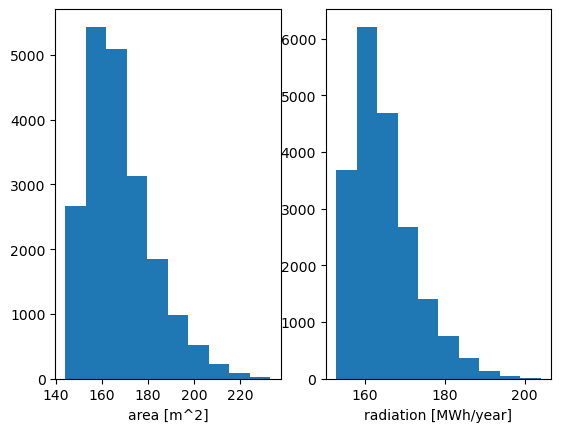

In [4]:
fig, axs = plt.subplots(1,num_output)
for o in range(num_output):
    axs[o].hist(output[:,o])
    axs[o].set_xlabel(label_output[o])

Scatterplot to show the correlation between the two outputs (area and radiation)

Text(0, 0.5, 'radiation [MWh/year]')

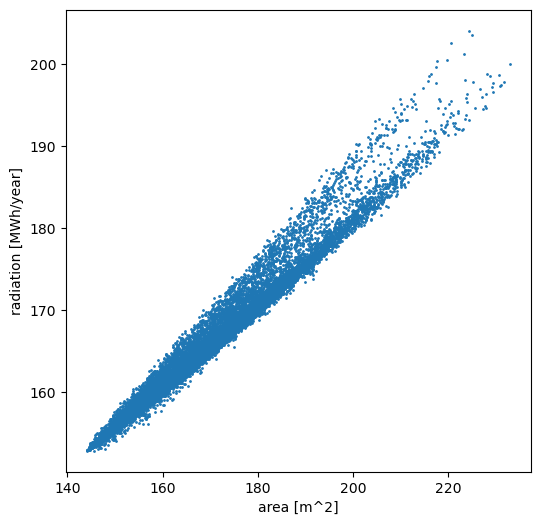

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(output[:,0], output[:,1], s = 1)
ax.set_xlabel(label_output[0])
ax.set_ylabel(label_output[1])

# Signature of the function

You are required to implement the function `checkpoint_implementation(params)`, which implement the surrogate model. 

The input argument params is a NumPy array of shape (num_samples, 8), where each row represents a roof configuration defined by the eight geometric parameters. The function must work for an arbitrary number of samples.

The function should return a NumPy array predicted_output with shape (num_samples, 2), matching the structure of the reference outputs provided in the dataset. The second column must contain the predicted annual irradiance, and the first column must contain the predicted roof surface area. 

# Linear Regression

In [6]:
# Addestramento (modello di regressione lineare multivariata)
model = MultiOutputRegressor(LinearRegression())  # qui creo due regress linear indip (uno per area e uno per irradianza)
model.fit(params, output)       # qui addestro: input params(20000, 80), output(20000,2)

#!!!Per capire: il modello fa  2 csoe:
# area = a₁·p1 + a₂·p2 + ... + a₈·p8 + b₁
# irradianza = c₁·p1 + c₂·p2 + ... + c₈·p8 + b₂

def checkpoint_implementation(params):
    #
    # predicted_output must be a numpy array with the same with shape (num samples,2)

    predicted_output = model.predict(params)
    
    return predicted_output

In [7]:
# Test sulla totalità del dataset
predictions = checkpoint_implementation(params)

print("Predizioni sui primi 5 campioni:")
print("Predetti:\n", predictions[:5])
print("\nReali:\n", output[:5])

# Calcola l'errore medio (MSE - Mean Squared Error)
from sklearn.metrics import mean_squared_error, r2_score

mse_area = mean_squared_error(output[:, 0], predictions[:, 0])
mse_radiation = mean_squared_error(output[:, 1], predictions[:, 1])
r2_area = r2_score(output[:, 0], predictions[:, 0])
r2_radiation = r2_score(output[:, 1], predictions[:, 1])

print(f"\nSuperficie (area):")
print(f"  MSE: {mse_area:.6f}")
print(f"  R²: {r2_area:.6f}")
print(f"\nIrradianza (radiation):")
print(f"  MSE: {mse_radiation:.6f}")
print(f"  R²: {r2_radiation:.6f}")

Predizioni sui primi 5 campioni:
Predetti:
 [[168.73316476 164.5926398 ]
 [168.96054596 165.90926326]
 [162.27814593 161.72538699]
 [146.12094785 152.62567262]
 [162.40660775 161.78405329]]

Reali:
 [[160.838963 160.68    ]
 [161.405398 160.532   ]
 [161.027721 160.701   ]
 [154.611087 158.457   ]
 [160.530018 161.155   ]]

Superficie (area):
  MSE: 52.025959
  R²: 0.746237

Irradianza (radiation):
  MSE: 16.443098
  R²: 0.727656


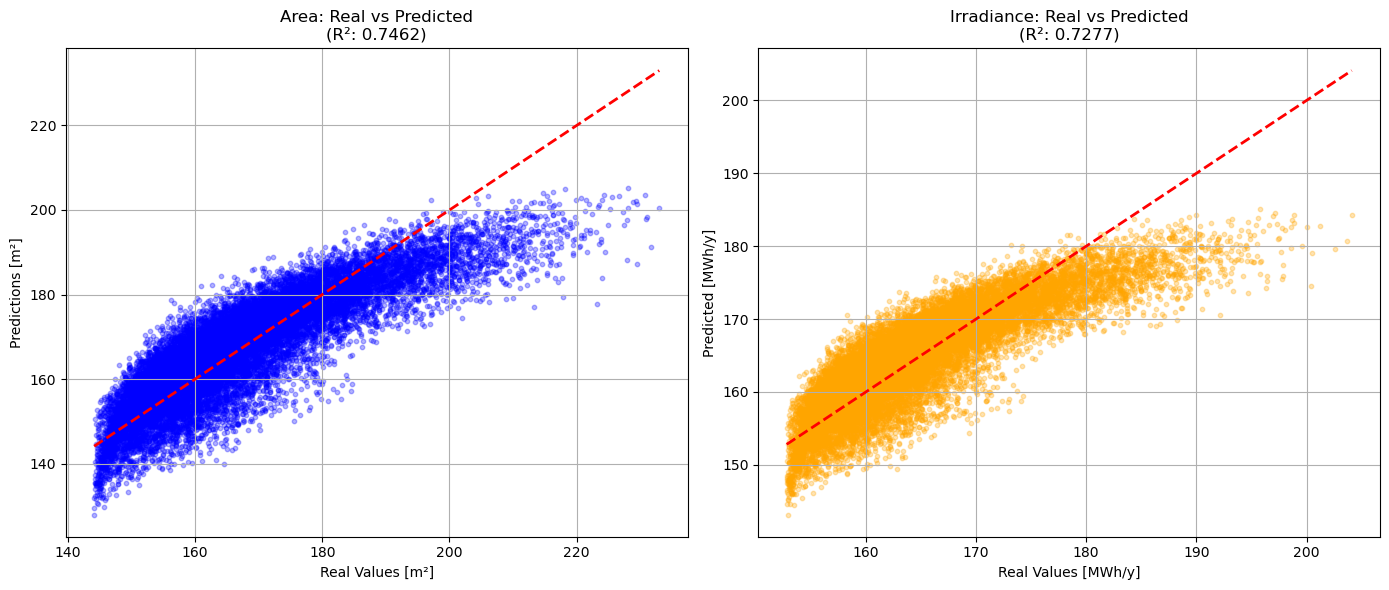

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Area
ax[0].scatter(output[:, 0], predictions[:, 0], alpha=0.3, color='blue', s=10)
ax[0].plot([output[:, 0].min(), output[:, 0].max()], [output[:, 0].min(), output[:, 0].max()], 'r--', lw=2)
ax[0].set_title(f'Area: Real vs Predicted\n(R²: {r2_area:.4f})')
ax[0].set_xlabel('Real Values [m²]')
ax[0].set_ylabel('Predictions [m²]')
ax[0].grid(True)

# Radiation
ax[1].scatter(output[:, 1], predictions[:, 1], alpha=0.3, color='orange', s=10)
ax[1].plot([output[:, 1].min(), output[:, 1].max()], [output[:, 1].min(), output[:, 1].max()], 'r--', lw=2)
ax[1].set_title(f'Irradiance: Real vs Predicted\n(R²: {r2_radiation:.4f})')
ax[1].set_xlabel('Real Values [MWh/y]')
ax[1].set_ylabel('Predicted [MWh/y]')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Polynomial Regression

In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


scaler_in = StandardScaler()
params_raw = data[:, :8]
output_raw = data[:, 8:]

params_standardized = scaler_in.fit_transform(params_raw)

X_train = scaler_in.fit_transform(params_raw)
y_train = output_raw # Area e Irradianza

gradi = [1, 2, 3, 4]
risultati = []

for g in gradi:
    for nome_algoritmo, regressore in [('Ridge', Ridge(alpha=0.1)), 
                                       ('Lasso', Lasso(alpha=0.01, max_iter=20000))]:
        
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=g)),
            ('reg', regressore)
        ])

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_train)
        mse = mean_squared_error(y_train, y_pred)
        r2 = r2_score(y_train, y_pred)
        
        n_features = model.named_steps['poly'].n_output_features_
        
        risultati.append({
            'Modello': nome_algoritmo,
            'Grado': g,
            'MSE': mse,
            'R2': r2,
            'Features': n_features
        })

df_res = pd.DataFrame(risultati)
print(df_res.to_string(index=False))



Modello  Grado       MSE       R2  Features
  Ridge      1 34.234528 0.736947         9
  Lasso      1 34.235331 0.736938         9
  Ridge      2 11.049860 0.913474        45
  Lasso      2 11.054329 0.913427        45
  Ridge      3  9.786414 0.923564       165
  Lasso      3  9.816293 0.923248       165
  Ridge      4  9.219267 0.928036       495
  Lasso      4  9.318017 0.927039       495


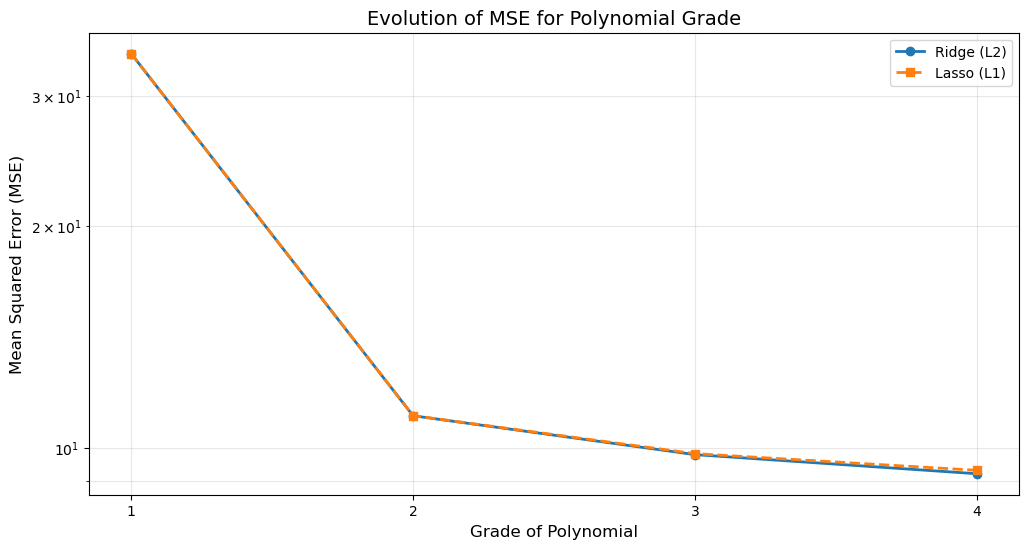

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df_ridge = df_res[df_res['Modello'] == 'Ridge']
df_lasso = df_res[df_res['Modello'] == 'Lasso']


plt.plot(df_ridge['Grado'], df_ridge['MSE'], marker='o', label='Ridge (L2)', linewidth=2, color='#1f77b4')
plt.plot(df_lasso['Grado'], df_lasso['MSE'], marker='s', label='Lasso (L1)', linewidth=2, linestyle='--', color='#ff7f0e')


plt.title('Evolution of MSE for Polynomial Grade', fontsize=14)
plt.xlabel('Grade of Polynomial', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(gradi)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()


plt.show()


Si nota come vi sia un evidente miglioramento dell'errore passando al grado 2, ma poi si assiste ad un fenomeno di overfitting che porta ad un aumento dell'errore per i gradi successivi, nonostante l'aumento esponenziale del numero di feature.


# Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. SPLIT DEI DATI: separiamo training (80%) e test (20%)
#    Importante: non testare sugli stessi dati usati per addestrare!
X_train, X_test, y_train, y_test = train_test_split(
    params,    # input: 8 parametri geometrici
    output,    # output: [area, irradianza]
    test_size=0.2,      # 20% per test
    random_state=42     # per riproducibilità
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set: {X_test.shape[0]} campioni")

# 2. CREAZIONE E ADDESTRAMENTO DEL MODELLO RANDOM FOREST
#    RandomForestRegressor parametri principali:
#    - n_estimators: numero di alberi nella foresta (più = meglio ma più lento)
#    - max_depth: profondità massima degli alberi (None = nessun limite)
#    - random_state: seed per riproducibilità
#    - n_jobs=-1: usa tutti i core della CPU

rf_model = RandomForestRegressor(
    n_estimators=100,   # 100 alberi decisionali
    max_depth=None,     # alberi crescono fino a foglie pure
    random_state=42,
    n_jobs=-1           # parallelizza su tutti i core
)

# fit() addestra il modello: impara la relazione params -> output
rf_model.fit(X_train, y_train)

# 3. PREDIZIONI sul test set
rf_predictions = rf_model.predict(X_test)

# 4. VALUTAZIONE
mse_area_rf = mean_squared_error(y_test[:, 0], rf_predictions[:, 0])
mse_radiation_rf = mean_squared_error(y_test[:, 1], rf_predictions[:, 1])
r2_area_rf = r2_score(y_test[:, 0], rf_predictions[:, 0])
r2_radiation_rf = r2_score(y_test[:, 1], rf_predictions[:, 1])

print(f"\n=== RANDOM FOREST - Risultati su TEST SET ===")
print(f"Superficie (area):")
print(f"  MSE: {mse_area_rf:.6f}")
print(f"  R²: {r2_area_rf:.6f}")
print(f"\nIrradianza (radiation):")
print(f"  MSE: {mse_radiation_rf:.6f}")
print(f"  R²: {r2_radiation_rf:.6f}")

Training set: 16000 campioni
Test set: 4000 campioni

=== RANDOM FOREST - Risultati su TEST SET ===
Superficie (area):
  MSE: 17.693274
  R²: 0.914043

Irradianza (radiation):
  MSE: 5.847890
  R²: 0.904414


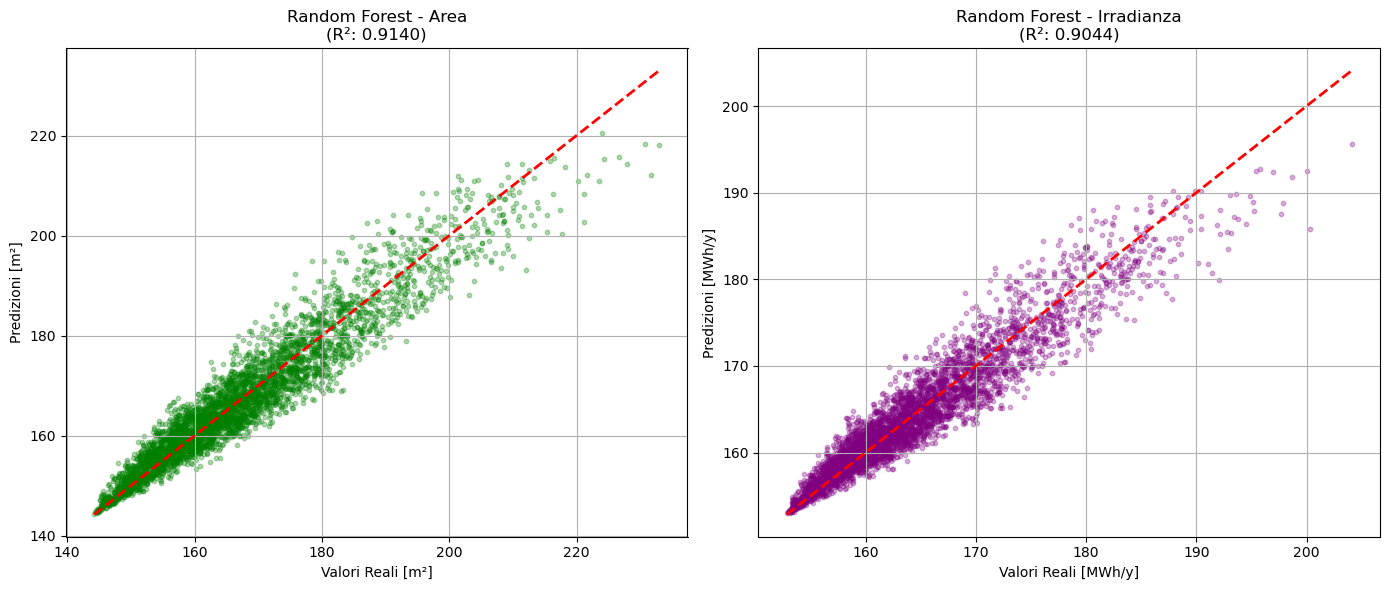

In [12]:
# Visualizzazione: Random Forest - Real vs Predicted
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Area
ax[0].scatter(y_test[:, 0], rf_predictions[:, 0], alpha=0.3, color='green', s=10)
ax[0].plot([y_test[:, 0].min(), y_test[:, 0].max()], 
           [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
ax[0].set_title(f'Random Forest - Area\n(R²: {r2_area_rf:.4f})')
ax[0].set_xlabel('Valori Reali [m²]')
ax[0].set_ylabel('Predizioni [m²]')
ax[0].grid(True)

# Radiation
ax[1].scatter(y_test[:, 1], rf_predictions[:, 1], alpha=0.3, color='purple', s=10)
ax[1].plot([y_test[:, 1].min(), y_test[:, 1].max()], 
           [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
ax[1].set_title(f'Random Forest - Irradianza\n(R²: {r2_radiation_rf:.4f})')
ax[1].set_xlabel('Valori Reali [MWh/y]')
ax[1].set_ylabel('Predizioni [MWh/y]')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Confronto equo: addestriamo anche Linear Regression sullo stesso split
lr_model = MultiOutputRegressor(LinearRegression())
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Metriche Linear Regression su test set
r2_area_lr = r2_score(y_test[:, 0], lr_predictions[:, 0])
r2_radiation_lr = r2_score(y_test[:, 1], lr_predictions[:, 1])
mse_area_lr = mean_squared_error(y_test[:, 0], lr_predictions[:, 0])
mse_radiation_lr = mean_squared_error(y_test[:, 1], lr_predictions[:, 1])

# Tabella di confronto
print("=" * 60)
print("CONFRONTO MODELLI (valutati su TEST SET)")
print("=" * 60)
print(f"{'Metrica':<25} {'Linear Reg.':<15} {'Random Forest':<15}")
print("-" * 60)
print(f"{'R² Area':<25} {r2_area_lr:<15.4f} {r2_area_rf:<15.4f}")
print(f"{'R² Irradianza':<25} {r2_radiation_lr:<15.4f} {r2_radiation_rf:<15.4f}")
print(f"{'MSE Area':<25} {mse_area_lr:<15.4f} {mse_area_rf:<15.4f}")
print(f"{'MSE Irradianza':<25} {mse_radiation_lr:<15.4f} {mse_radiation_rf:<15.4f}")
print("=" * 60)

# Quale modello è migliore?
winner_area = "Random Forest" if r2_area_rf > r2_area_lr else "Linear Regression"
winner_rad = "Random Forest" if r2_radiation_rf > r2_radiation_lr else "Linear Regression"
print(f"\nMigliore per Area: {winner_area}")
print(f"Migliore per Irradianza: {winner_rad}")

CONFRONTO MODELLI (valutati su TEST SET)
Metrica                   Linear Reg.     Random Forest  
------------------------------------------------------------
R² Area                   0.7482          0.9140         
R² Irradianza             0.7293          0.9044         
MSE Area                  51.8390         17.6933        
MSE Irradianza            16.5591         5.8479         

Migliore per Area: Random Forest
Migliore per Irradianza: Random Forest


In [15]:
# Funzione checkpoint con Random Forest (addestrato su TUTTI i dati)
rf_model_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_full.fit(params, output)

def checkpoint_implementation_rf(params_input):
    """
    Surrogate model basato su Random Forest.
    
    Input: params_input - array (num_samples, 8) con i parametri geometrici
    Output: array (num_samples, 2) con [area, irradianza]
    """
    predicted_output = rf_model_full.predict(params_input)
    return predicted_output

print("Modello Random Forest addestrato su tutti i 20000 campioni.")

Modello Random Forest addestrato su tutti i 20000 campioni.


# Neural Networks

In [16]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from sklearn.preprocessing import StandardScaler
import optax 

# DEFINIZIONE  RETE NEURALE
class RoofNet(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=64)(x)
        x = nn.relu(x)
        x = nn.Dense(features=64)(x)
        x = nn.relu(x)
        x = nn.Dense(features=2)(x) # output: Area e Irradianza
        return x

# Loss
# calcolare l'errore (MSE)
def loss_fn(params, x, y):
    predictions = RoofNet().apply({'params': params}, x)
    return jnp.mean((predictions - y) ** 2)

# Inizialization
model = RoofNet()
key = jax.random.PRNGKey(42)

params = model.init(key, jnp.ones((1, 8)))['params']

# ottimizzatore Adam
optimizer = optax.adam(learning_rate=0.001)
opt_state = optimizer.init(params)

# AGGIORNAMENTO
@jax.jit # accelera il codice sulla GPU
def update_step(params, opt_state, x, y):
    # gradiente
    loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
    
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss



data = np.genfromtxt('SCTdata20K.csv', delimiter=';')
params_raw = data[:, :8]
output_raw = data[:, 8:]

# Conversione Irradianza in MWh/y
output_raw[:, 1] = output_raw[:, 1] * 1e3

scaler_in = StandardScaler()

#  (x - media) / dev_std
params_standardized = scaler_in.fit_transform(params_raw)

# Conversione in array JAX
x_train = jnp.array(params_standardized)
y_train = jnp.array(output_raw)


history_loss = []


x_train = jnp.array(params_standardized) 
y_train = jnp.array(output_raw)    

print("Addestramento della Rete Neurale:")
for epoch in range(3001):
    params, opt_state, loss = update_step(params, opt_state, x_train, y_train)
    history_loss.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoca {epoch}, Errore (Loss): {loss:.4f}")


nn_params = params


Addestramento della Rete Neurale:
Epoca 0, Errore (Loss): 27712.4316
Epoca 100, Errore (Loss): 16998.3906
Epoca 200, Errore (Loss): 852.0879
Epoca 300, Errore (Loss): 543.2979
Epoca 400, Errore (Loss): 474.7104
Epoca 500, Errore (Loss): 431.1679
Epoca 600, Errore (Loss): 401.4854
Epoca 700, Errore (Loss): 378.7669
Epoca 800, Errore (Loss): 358.7036
Epoca 900, Errore (Loss): 339.0033
Epoca 1000, Errore (Loss): 318.3918
Epoca 1100, Errore (Loss): 296.0052
Epoca 1200, Errore (Loss): 272.5725
Epoca 1300, Errore (Loss): 247.3124
Epoca 1400, Errore (Loss): 219.5700
Epoca 1500, Errore (Loss): 188.6737
Epoca 1600, Errore (Loss): 153.3906
Epoca 1700, Errore (Loss): 114.7434
Epoca 1800, Errore (Loss): 77.3281
Epoca 1900, Errore (Loss): 45.1477
Epoca 2000, Errore (Loss): 27.2671
Epoca 2100, Errore (Loss): 19.9658
Epoca 2200, Errore (Loss): 17.0248
Epoca 2300, Errore (Loss): 15.5010
Epoca 2400, Errore (Loss): 14.5301
Epoca 2500, Errore (Loss): 13.8335
Epoca 2600, Errore (Loss): 13.3059
Epoca 2700,

In [17]:
def checkpoint_implementation_nn(params_input):
    # params_input è un array (n_samples, 8)

    params_std = scaler_in.transform(params_input)

    # Convertiamo in JAX
    x_jax = jnp.array(params_std)

    # Predizione usando i pesi della rete neurale addestrata
    predictions = model.apply({'params': nn_params}, x_jax)

    return np.array(predictions)


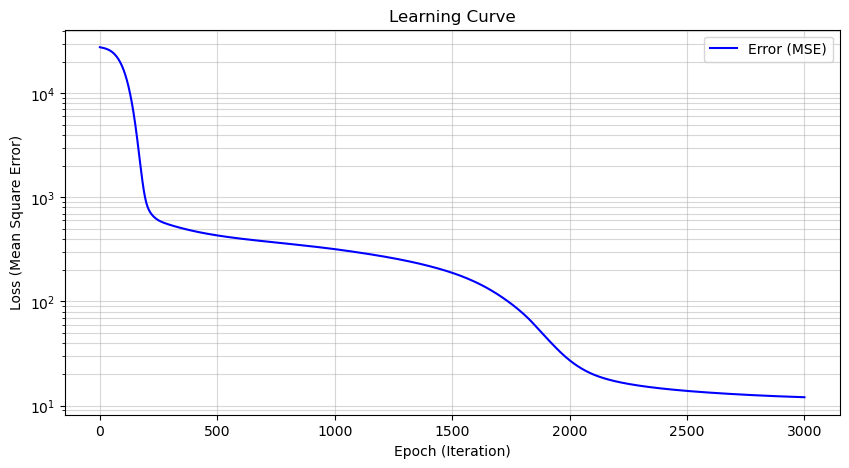

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_loss, color='blue', label='Error (MSE)')
plt.title('Learning Curve')
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Loss (Mean Square Error)')

# Usiamo la scala logaritmica se l'errore cala di molti ordini di grandezza
# Questo permette di vedere meglio i miglioramenti verso la fine
plt.yscale('log') 

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

Si nota una curvatura ulteriore in corrispondenza delle iterazioni 1500-2500: la curva riprende a scendere drasticamente.
Questo significa che dopo molto tempo la rete neurale ha trovato una configurazione dei pesi che spiega molto meglio i dati.

In [19]:
#  (1500-3000 epoche): La svolta, la curva riprende a scendere drasticamente.
# Questo significa che dopo molto tempo la rete ha trovato una configurazione dei pesi che spiega molto meglio i dati.

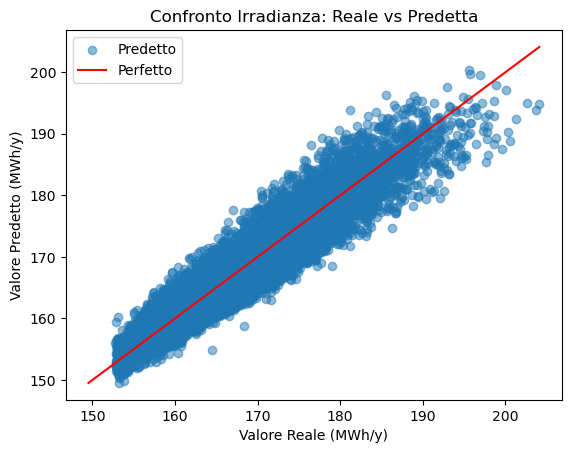

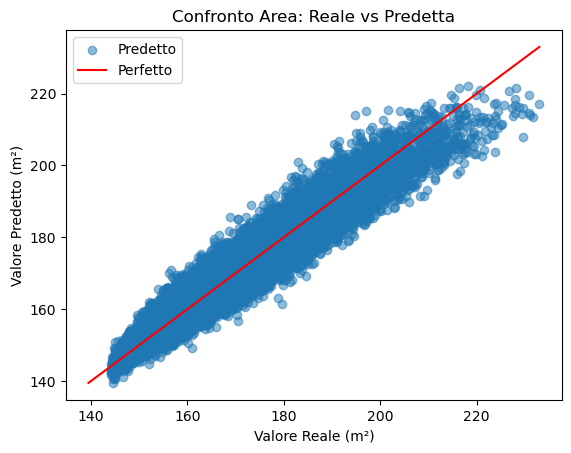

In [20]:
# scatter plot per confrontare predizioni e valori reali
# Irradianza
y_reale_irradianza = output[:, 1]
y_predetto_irradianza = checkpoint_implementation_nn(params_raw)[:, 1]
plt.scatter(y_reale_irradianza, y_predetto_irradianza, alpha=0.5, label='Predetto')

# Linea di perfezione: usiamo min/max dei dati per coprire tutta la scala
irr_min = min(y_reale_irradianza.min(), y_predetto_irradianza.min())
irr_max = max(y_reale_irradianza.max(), y_predetto_irradianza.max())
plt.plot([irr_min, irr_max], [irr_min, irr_max], color='red', label='Perfetto')

plt.title('Confronto Irradianza: Reale vs Predetta')
plt.xlabel('Valore Reale (MWh/y)')
plt.ylabel('Valore Predetto (MWh/y)')
plt.legend()
plt.show()

# Area
y_reale_area = output[:, 0]
y_predetto_area = checkpoint_implementation_nn(params_raw)[:, 0]
plt.scatter(y_reale_area, y_predetto_area, alpha=0.5, label='Predetto')

area_min = min(y_reale_area.min(), y_predetto_area.min())
area_max = max(y_reale_area.max(), y_predetto_area.max())
plt.plot([area_min, area_max], [area_min, area_max], color='red', label='Perfetto')

plt.title('Confronto Area: Reale vs Predetta')
plt.xlabel('Valore Reale (m²)')
plt.ylabel('Valore Predetto (m²)')
plt.legend()
plt.show()

### Final comparison between models

Let's compare all the models to find the best one.

                    CONFRONTO FINALE DEI MODELLI
              Modello  R² Area  R² Irradianza  MSE Area  MSE Irradianza
    Linear Regression 0.746237       0.727656 52.025959       16.443098
Poly Regression (g=2) 0.913474       0.913474 11.049860       11.049860
        Random Forest 0.914043       0.904414 17.693274        5.847890
       Neural Network 0.914118       0.893069 17.607327        6.456089


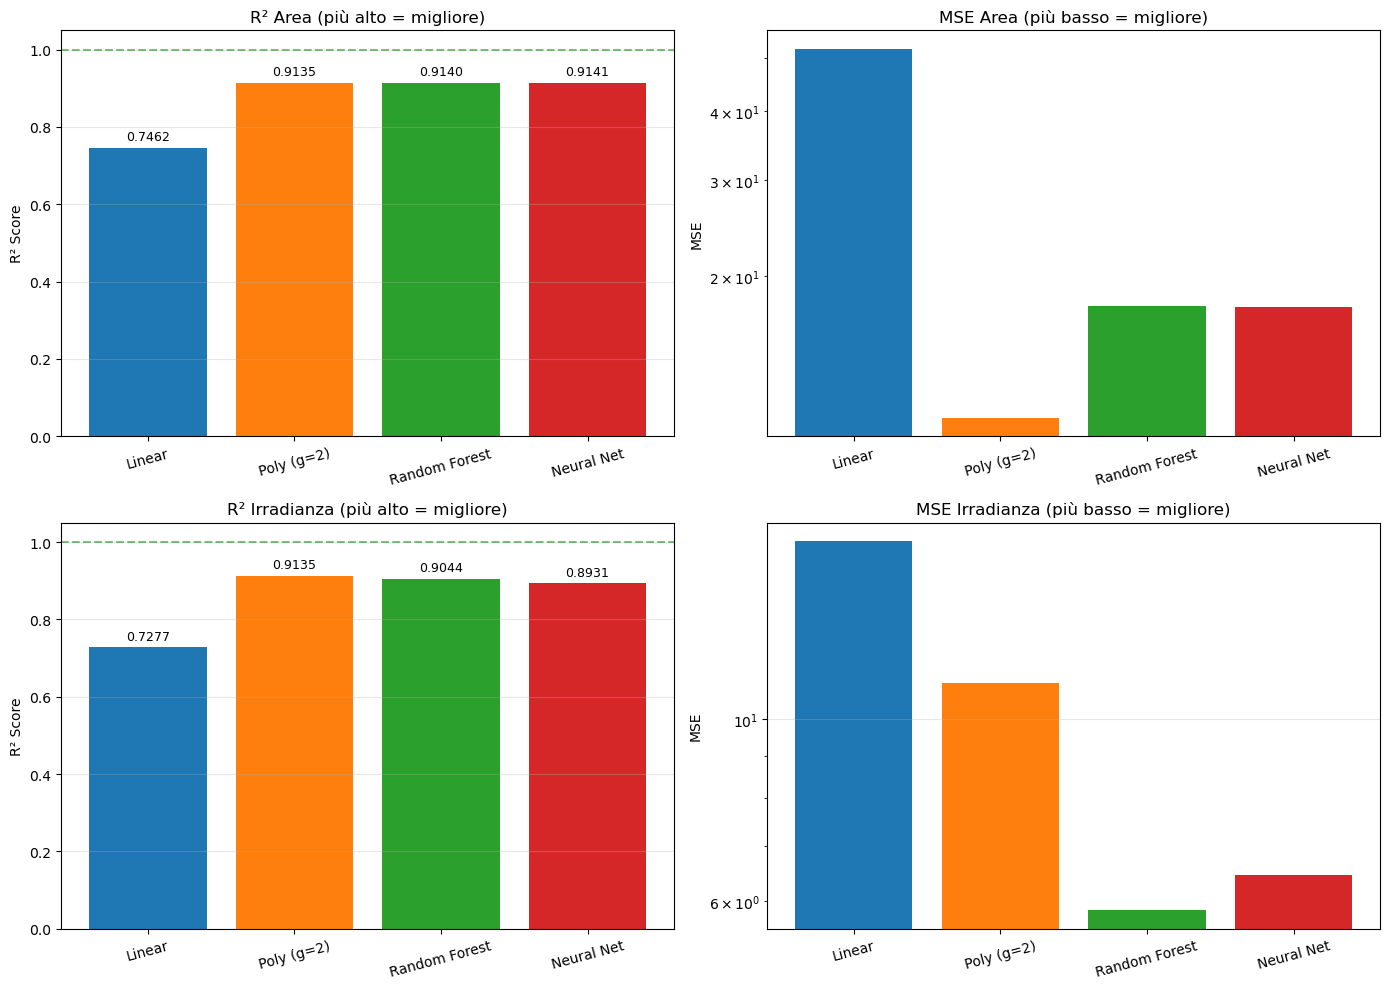


=== AREA ===
  Best R²: Neural Net (0.9141)
  Lowest MSE: Poly (g=2) (11.0499)

=== IRRADIANZA ===
  Best R²: Poly (g=2) (0.9135)
  Lowest MSE: Random Forest (5.8479)


In [22]:
import pandas as pd

# Calcolo metriche Neural Network
nn_predictions = checkpoint_implementation_nn(params_raw)
r2_area_nn = r2_score(output[:, 0], nn_predictions[:, 0])
r2_radiation_nn = r2_score(output[:, 1], nn_predictions[:, 1])
mse_area_nn = mean_squared_error(output[:, 0], nn_predictions[:, 0])
mse_radiation_nn = mean_squared_error(output[:, 1], nn_predictions[:, 1])

# Polynomial Regression migliore (grado 2, Ridge)
poly_best = df_res[(df_res['Grado'] == 2) & (df_res['Modello'] == 'Ridge')].iloc[0]

# Tabella confronto
results = pd.DataFrame({
    'Modello': ['Linear Regression', 'Poly Regression (g=2)', 'Random Forest', 'Neural Network'],
    'R² Area': [r2_area, poly_best['R2'], r2_area_rf, r2_area_nn],
    'R² Irradianza': [r2_radiation, poly_best['R2'], r2_radiation_rf, r2_radiation_nn],
    'MSE Area': [mse_area, poly_best['MSE'], mse_area_rf, mse_area_nn],
    'MSE Irradianza': [mse_radiation, poly_best['MSE'], mse_radiation_rf, mse_radiation_nn],
})

print("=" * 80)
print("                    CONFRONTO FINALE DEI MODELLI")
print("=" * 80)
print(results.to_string(index=False))
print("=" * 80)

# Grafico confronto con 4 subplot (2x2)
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

modelli = ['Linear', 'Poly (g=2)', 'Random Forest', 'Neural Net']
x_pos = np.arange(len(modelli))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# ===============================================
# RIGA 1: AREA
# ===============================================

# R² Area
r2_vals_area = [r2_area, poly_best['R2'], r2_area_rf, r2_area_nn]
ax[0, 0].bar(x_pos, r2_vals_area, color=colors)
ax[0, 0].set_ylabel('R² Score')
ax[0, 0].set_title('R² Area (più alto = migliore)')
ax[0, 0].set_xticks(x_pos)
ax[0, 0].set_xticklabels(modelli, rotation=15)
ax[0, 0].set_ylim([0, 1.05])
ax[0, 0].axhline(y=1, color='green', linestyle='--', alpha=0.5)
ax[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(r2_vals_area):
    ax[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

# MSE Area
mse_vals_area = [mse_area, poly_best['MSE'], mse_area_rf, mse_area_nn]
ax[0, 1].bar(x_pos, mse_vals_area, color=colors)
ax[0, 1].set_ylabel('MSE')
ax[0, 1].set_title('MSE Area (più basso = migliore)')
ax[0, 1].set_xticks(x_pos)
ax[0, 1].set_xticklabels(modelli, rotation=15)
ax[0, 1].set_yscale('log')
ax[0, 1].grid(axis='y', alpha=0.3)

# ===============================================
# RIGA 2: IRRADIANZA
# ===============================================

# R² Irradianza (CORRETTO: usa r2_radiation, non r2_area)
r2_vals_rad = [r2_radiation, poly_best['R2'], r2_radiation_rf, r2_radiation_nn]
ax[1, 0].bar(x_pos, r2_vals_rad, color=colors)
ax[1, 0].set_ylabel('R² Score')
ax[1, 0].set_title('R² Irradianza (più alto = migliore)')
ax[1, 0].set_xticks(x_pos)
ax[1, 0].set_xticklabels(modelli, rotation=15)
ax[1, 0].set_ylim([0, 1.05])
ax[1, 0].axhline(y=1, color='green', linestyle='--', alpha=0.5)
ax[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(r2_vals_rad):
    ax[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

# MSE Irradianza
mse_vals_rad = [mse_radiation, poly_best['MSE'], mse_radiation_rf, mse_radiation_nn]
ax[1, 1].bar(x_pos, mse_vals_rad, color=colors)
ax[1, 1].set_ylabel('MSE')
ax[1, 1].set_title('MSE Irradianza (più basso = migliore)')
ax[1, 1].set_xticks(x_pos)
ax[1, 1].set_xticklabels(modelli, rotation=15)
ax[1, 1].set_yscale('log')
ax[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identificazione vincitori
best_r2_area_idx = np.argmax(r2_vals_area)
best_mse_area_idx = np.argmin(mse_vals_area)
best_r2_rad_idx = np.argmax(r2_vals_rad)
best_mse_rad_idx = np.argmin(mse_vals_rad)

print(f"\n=== AREA ===")
print(f"  Best R²: {modelli[best_r2_area_idx]} ({r2_vals_area[best_r2_area_idx]:.4f})")
print(f"  Lowest MSE: {modelli[best_mse_area_idx]} ({mse_vals_area[best_mse_area_idx]:.4f})")
print(f"\n=== IRRADIANZA ===")
print(f"  Best R²: {modelli[best_r2_rad_idx]} ({r2_vals_rad[best_r2_rad_idx]:.4f})")
print(f"  Lowest MSE: {modelli[best_mse_rad_idx]} ({mse_vals_rad[best_mse_rad_idx]:.4f})")